# **Week 6 - Pre-requisite of LLM Fine-Tuning**

**Use case:** predicting football player value based on the description of their attributes and strengths

### **Pre-Requisite Steps covered in Week 6:**

**1. Data Curation**

**2. Data pre-processing**

**3. Evaluation, baselines, traditional ML**

**4. Deep learning and LLMs**

## **1. Data Curation**

**1.1. Import libraries, login to HF account, and load the dataset**

In [8]:
# imports

import os
from dotenv import load_dotenv
load_dotenv(override=True)
from huggingface_hub import login
from datasets import load_dataset
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm
import numpy as np
import random
from mv_estimator.mv_items import PlayerItem
from mv_estimator.mv_parser import parse

In [3]:
# Log in to HuggingFace - if you get a "Note" about Environment variable being set, ignore it

hf_token = os.environ['HF_TOKEN']
login(hf_token, add_to_git_credential=True)

Note: Environment variable`HF_TOKEN` is set and is the current active token independently from the token you've just configured.


In [52]:
# Load the dataset
# Install the kagglehub first by executing: uv pip install kagglehub in PowerShell

import kagglehub
import pandas as pd
path = kagglehub.dataset_download("davidcariboo/player-scores")
players = pd.read_csv(f"{path}/players.csv")

# Verify the data schema from Kaggle
# Output should contains market_value_in_eur, name, position, sub_position, foot, height_in_cm, country_of_citizenship, current_club_name, contract_expiration_date, date_of_birth
print(players.columns.tolist())
print(f"Number of Players: {len(players)}")

['player_id', 'first_name', 'last_name', 'name', 'last_season', 'current_club_id', 'player_code', 'country_of_birth', 'city_of_birth', 'country_of_citizenship', 'date_of_birth', 'sub_position', 'position', 'foot', 'height_in_cm', 'contract_expiration_date', 'agent_name', 'image_url', 'international_caps', 'international_goals', 'current_national_team_id', 'url', 'current_club_domestic_competition_id', 'current_club_name', 'market_value_in_eur', 'highest_market_value_in_eur']
Number of Players: 50149


**1.2. Investigate the dataset**

In [5]:
# Try check the pd data in any arbitrary row
players.loc[1]

player_id                                                                              26
first_name                                                                          Roman
last_name                                                                    Weidenfeller
name                                                                   Roman Weidenfeller
last_season                                                                          2017
current_club_id                                                                        16
player_code                                                            roman-weidenfeller
country_of_birth                                                                  Germany
city_of_birth                                                                        Diez
country_of_citizenship                                                            Germany
date_of_birth                                                         1980-08-06 00:00:00
sub_positi

In [6]:
# Try check the most expensive player value

max_value = 0
max_player = None

for _, datapoint in tqdm(players.iterrows(), total=len(players)):
    try:
        value = float(datapoint["market_value_in_eur"])
        if value > max_value:
            max_player = datapoint
            max_value = value
    except ValueError:
        pass

print(f"The most expensive player is {max_player['name']} and it costs {max_value:,.2f}")

  0%|          | 0/50149 [00:00<?, ?it/s]

The most expensive player is Erling Haaland and it costs 200,000,000.00


In [7]:
# Try check the cheapest player value
min_value = 8000000
min_player = None

for _, datapoint in tqdm(players.iterrows(), total=len(players)):
    try:
        value = float(datapoint["market_value_in_eur"])
        if value < min_value:
            min_player = datapoint
            min_value = value
    except ValueError:
        pass

print(f"The cheapest player is {min_player['name']} from {min_player['current_club_name']} and it costs {min_value:,.2f}")

  0%|          | 0/50149 [00:00<?, ?it/s]

The cheapest player is Brian Murphy from Cardiff City and it costs 10,000.00


**1.3. Load the dataset into PlayerItem objects**

In [8]:
# Load into PlayerItem objects
# Key difference between HF & Kaggle dataset is that HF dataset is a dictionary of datapoints, while Kaggle dataset is a pandas dataframe
# While handling pandas dataset, we use .to_dict() to convert the dataframe into a dictionary, then the data points consist of _ and row

items = [parse(row.to_dict()) for _, row in tqdm(players.iterrows(), total=len(players))]
items = [item for item in items if item is not None]
print(f"There are {len(items):,} items from {len(players):,} datapoints")

# There are 41,528 items from 50,149 datapoints

  0%|          | 0/50149 [00:00<?, ?it/s]

There are 41,528 items from 50,149 datapoints


**1.4. Sanity-check the items**

In [14]:
# Check the items content
items[3]

<Lúcio = €200,000>

In [15]:
# Check the full description of the loaded items

print(items[3].full)

Name: Lúcio
Position: Defender (Centre-Back)
Age: 48
Nationality: Brazil
Current club: Juventus FC


**1.5. Define arrays to store the data lengths and the player values**

*To check the maximum and minimum values*

In [17]:
# Defining the prices and description lengths datapoints

prices = [item.value for item in items]
lengths = [len(item.full) for item in items]

In [33]:
# Longest and shortest descriptions
max_length = max(lengths)
max_length_item = items[lengths.index(max_length)]
print(max_length_item.full)
print(f"The length is: {len(max_length_item.full)}")

min_length = min(lengths)
min_length_item = items[lengths.index(min_length)]
print("\n"+min_length_item.full)
print(f"The length is: {len(min_length_item.full)}")

Name: Konstantinos Chatzidimpas
Position: Midfield (Defensive Midfield)
Age: 27
Preferred foot: right
Height: 183 cm
Nationality: Greece
Current club: Panthessalonikios Athlitikos Omilos Konstantinoupoliton
Contract until: 2023-06-30
The length is: 233

Name: Yousef Kara
Position: Defender (Right-Back)
Age: 25
Nationality: Libya
The length is: 76


In [50]:
top = sorted(items, key=lambda x: x.value, reverse=True)[:30]
for item in top:
    print(item.value, "-", item.name)

200000000.0 - Erling Haaland
200000000.0 - Lamine Yamal
180000000.0 - Kylian Mbappé
150000000.0 - Michael Olise
150000000.0 - Pedri
140000000.0 - Vinicius Junior
140000000.0 - Vitinha
140000000.0 - Khvicha Kvaratskhelia
140000000.0 - João Neves
130000000.0 - Jude Bellingham
120000000.0 - Declan Rice
120000000.0 - Désiré Doué
110000000.0 - Bukayo Saka
100000000.0 - Ousmane Dembélé
100000000.0 - Dominik Szoboszlai
100000000.0 - William Saliba
100000000.0 - Cole Palmer
100000000.0 - Julián Alvarez
100000000.0 - Jamal Musiala
100000000.0 - Florian Wirtz
100000000.0 - Fermín López
100000000.0 - Moisés Caicedo
90000000.0 - Federico Valverde
90000000.0 - Morgan Rogers
90000000.0 - Rayan Cherki
90000000.0 - Enzo Fernández
90000000.0 - Aleksandar Pavlovic
90000000.0 - Arda Güler
90000000.0 - Yan Diomande
85000000.0 - Alexander Isak


In [53]:
print(items[3].full)

Name: Lúcio
Position: Defender (Centre-Back)
Age: 48
Nationality: Brazil
Current club: Juventus FC


**1.6. Data Cleansing - Remove Duplication**

In [54]:
# Remove duplication

random.seed(42)
random.shuffle(items)

seen = set()
items = [x for x in tqdm(items) if not (x.name in seen or seen.add(x.name))]

seen = set()
items = [x for x in tqdm(items) if not (x.full in seen or seen.add(x.full))]

del seen
print(f"After deduplication, we have {len(items):,} items")

  0%|          | 0/41528 [00:00<?, ?it/s]

  0%|          | 0/40563 [00:00<?, ?it/s]

After deduplication, we have 40,563 items


In [60]:
# Sanity check
from collections import Counter
duplicate_names = [name for name, count in Counter(x.name for x in items).items() if count > 1]
print(f"{len(duplicate_names)} names still appear more than once after dedup")

0 names still appear more than once after dedup


**1.7. Check and analyze data distribution**

*After data is cleansed (de-duped)*

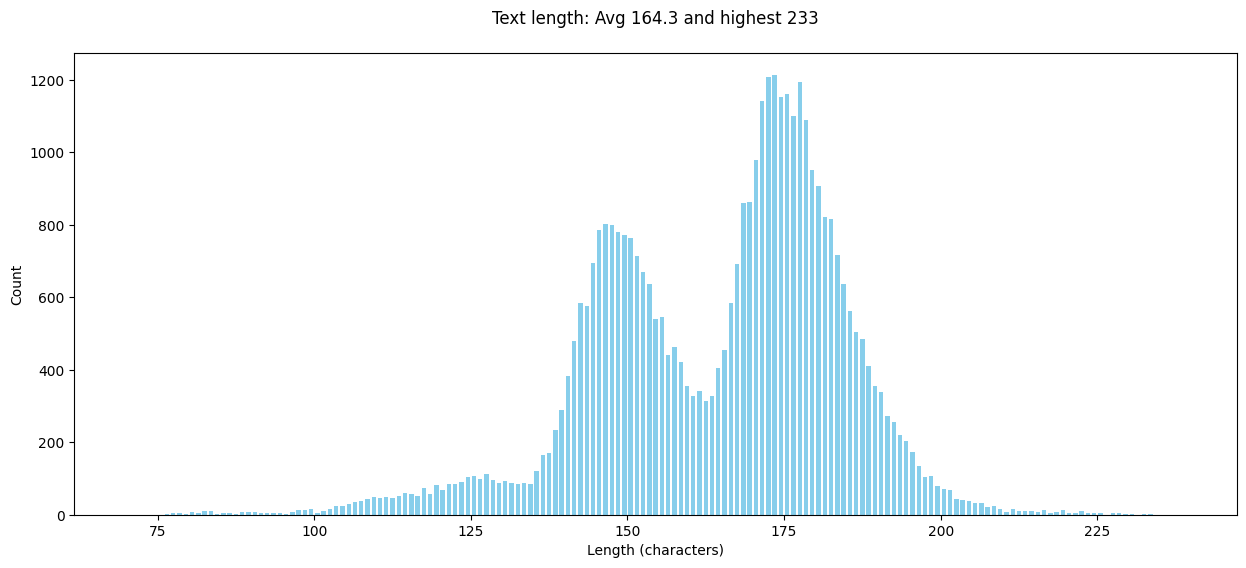

In [55]:
# Plot the distribution of lengths

lengths = [len(item.full) for item in items]
plt.figure(figsize=(15, 6))
plt.title(f"Text length: Avg {sum(lengths)/len(lengths):,.1f} and highest {max(lengths):,}\n")
plt.xlabel('Length (characters)')
plt.ylabel('Count')
plt.hist(lengths, rwidth=0.7, color="skyblue", bins=range(70, 240, 1))
plt.show()

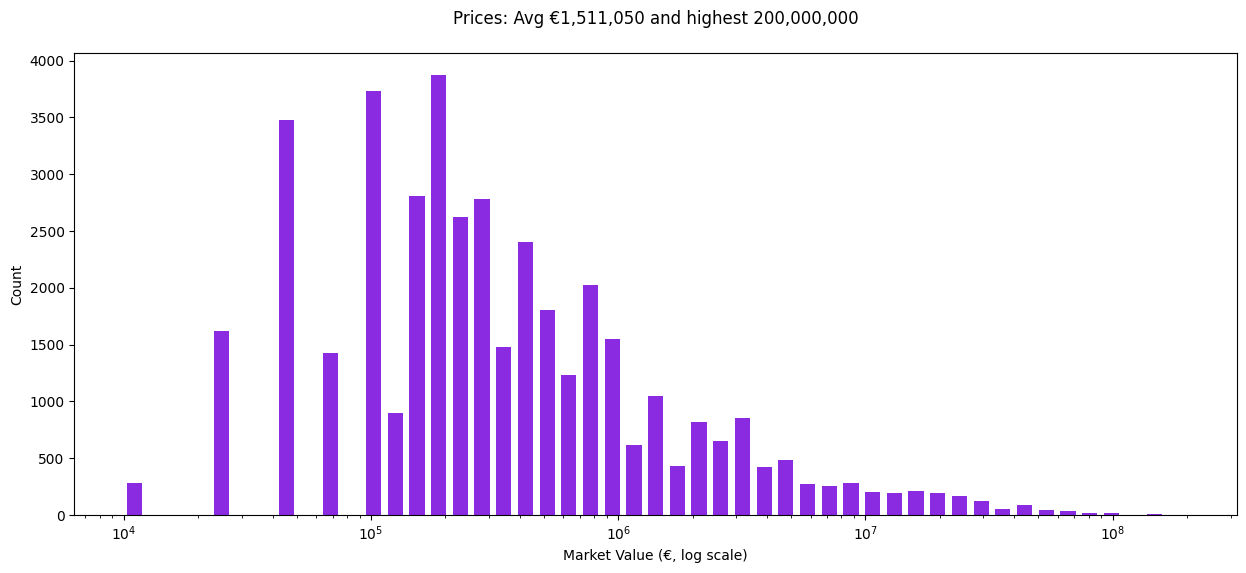

In [56]:
# Plot the distribution of prices using logarithmic scale
import numpy as np

log_bins = np.logspace(np.log10(min(prices)), np.log10(max(prices)), 50)

plt.figure(figsize=(15, 6))
plt.title(f"Prices: Avg €{sum(prices)/len(prices):,.0f} and highest {max(prices):,.0f}\n")
plt.xlabel('Market Value (€, log scale)')
plt.ylabel('Count')
plt.hist(prices, bins=log_bins, rwidth=0.7, color="blueviolet")
plt.xscale('log')
plt.show()

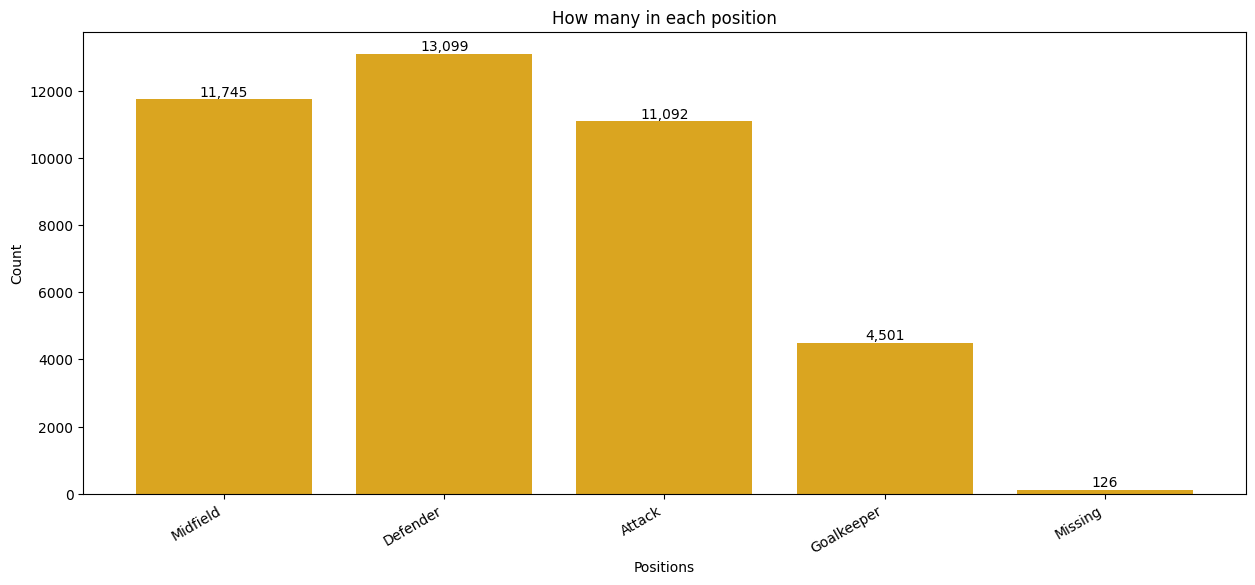

In [58]:
from collections import Counter
position_counts = Counter([item.position for item in items])

positions = position_counts.keys()
counts = [position_counts[position] for position in positions]

plt.figure(figsize=(15, 6))
plt.bar(positions, counts, color="goldenrod")
plt.title('How many in each position')
plt.xlabel('Positions')
plt.ylabel('Count')
plt.xticks(rotation=30, ha='right')

for i, v in enumerate(counts):
    plt.text(i, v, f"{v:,}", ha='center', va='bottom')

plt.show()

*Key Takeways from Data Distribution Check*
1. No data normalization is needed since the imbalance is not too far
2. All the datapoints will be used as sample (i.e. items = sample), no need to perform weighting and sampling

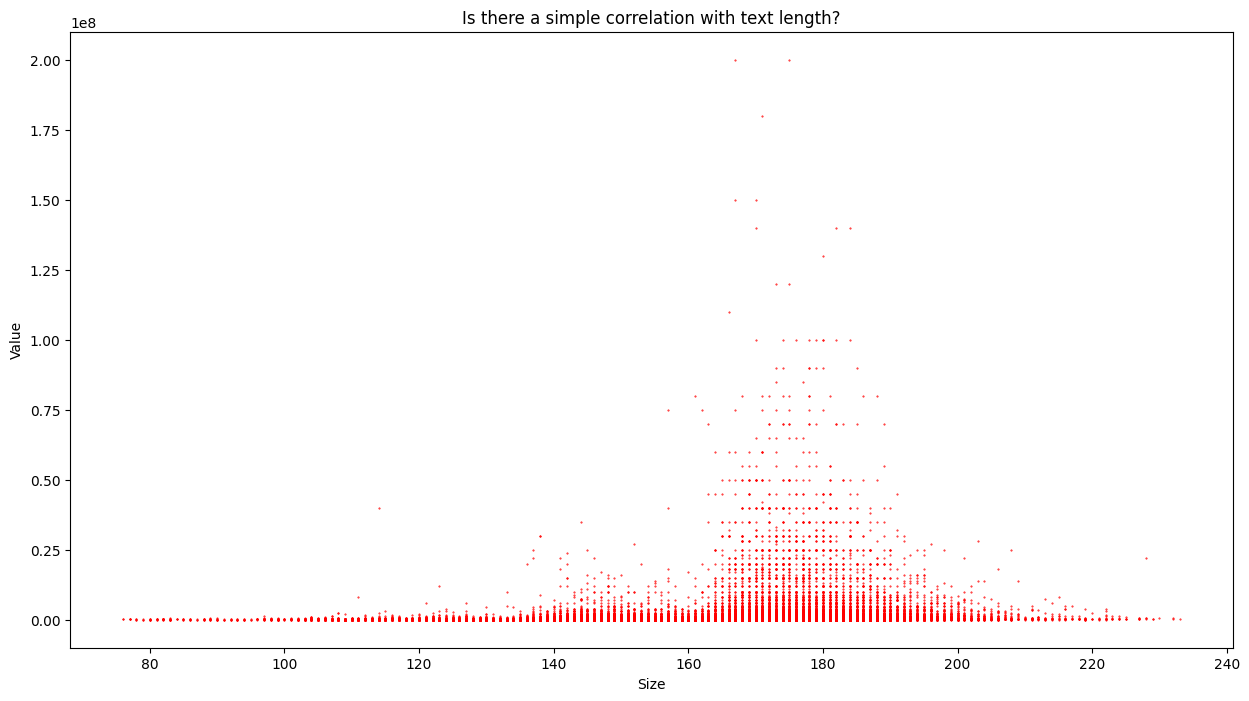

In [61]:
# How does the price vary with the character count?
# i.e. longer text tend to have higher price

sizes = [len(item.full) for item in items]
values = [item.value for item in items]

# Create the scatter plot
plt.figure(figsize=(15, 8))
plt.scatter(sizes, values, s=0.2, color="red")

# Add labels and title
plt.xlabel('Size')
plt.ylabel('Value')
plt.title('Is there a simple correlation with text length?')

# Display the plot
plt.show()

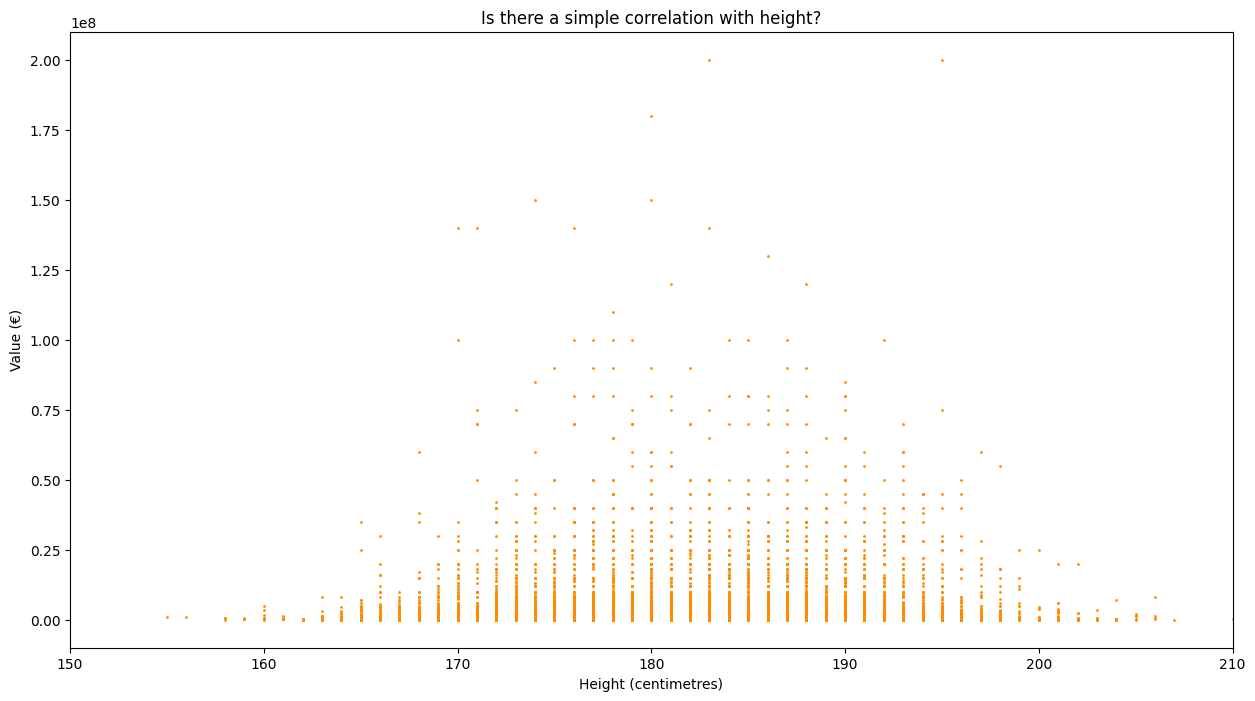

In [66]:
# How does value vary with height? Use the raw dataframe, since PlayerItem only
# stores individual attributes (height/foot/nationality/etc.) folded into `full`
# text, not as separate structured fields - mirroring Item's minimal design.

subset = players.dropna(subset=["height_in_cm", "market_value_in_eur"])

# Create the scatter plot
plt.figure(figsize=(15, 8))
plt.scatter(subset["height_in_cm"], subset["market_value_in_eur"], s=1, color="darkorange")

# Add labels and title
plt.xlabel('Height (centimetres)')
plt.ylabel('Value (€)')
plt.xlim(150, 210)
plt.title('Is there a simple correlation with height?')

# Display the plot
plt.show()

**1.8. Push the dataset into Huggingface Hub**

In [67]:
username = "farrasezra"
full = f"{username}/football_mv_raw_full"

# Total data size in items is: 40,563 items. All will be uploaded

# Define the splitting
train = items[:33_000]
val = items[33_000:37_000]
test = items[37_000:]

In [68]:
# Sanity check the splitting
print(len(items), len(train), len(val), len(test))
print(len(train) + len(val) + len(test) == len(items))  # sanity check they sum correctly

40563 33000 4000 3563
True


In [71]:
# Check if the data is sorted randomly (apparent on the alphabetically sorted or not) 
for item in items[:10]:
    print(item.name)
    
# Check whether the position is evenly distributed
from collections import Counter

def position_pct(subset):
    counts = Counter(item.position for item in subset)
    total = len(subset)
    return {pos: f"{count/total:.1%}" for pos, count in counts.most_common()}

print("Full:", position_pct(items))
print("Train:", position_pct(train))
print("Val:", position_pct(val))
print("Test:", position_pct(test))

Gianluca Musacci
Vangelis Koutsopoulos
Jason Noslin
Kolbeinn Thórdarson
Luca Fiordilino
Tristan Degreef
Roger Martí
Antonin Bobichon
Giorgi Chakvetadze
Manu García
Full: {'Defender': '32.3%', 'Midfield': '29.0%', 'Attack': '27.3%', 'Goalkeeper': '11.1%', 'Missing': '0.3%'}
Train: {'Defender': '32.2%', 'Midfield': '29.0%', 'Attack': '27.5%', 'Goalkeeper': '11.0%', 'Missing': '0.3%'}
Val: {'Defender': '32.6%', 'Midfield': '28.9%', 'Attack': '26.5%', 'Goalkeeper': '11.8%', 'Missing': '0.2%'}
Test: {'Defender': '32.4%', 'Midfield': '29.0%', 'Attack': '26.7%', 'Goalkeeper': '11.6%', 'Missing': '0.3%'}


In [72]:
PlayerItem.push_to_hub(full, train, val, test)

Uploading the dataset shards:   0%|          | 0/1 [00:00<?, ?it/s]

Creating parquet from Arrow format:   0%|          | 0/33 [00:00<?, ?ba/s]

Uploading the dataset shards:   0%|          | 0/1 [00:00<?, ?it/s]

Creating parquet from Arrow format:   0%|          | 0/4 [00:00<?, ?ba/s]

Uploading the dataset shards:   0%|          | 0/1 [00:00<?, ?it/s]

Creating parquet from Arrow format:   0%|          | 0/4 [00:00<?, ?ba/s]

## **2. Data Pre-processing**

*LLM will be used to re-write the description*

**2.1. Import libraries, load the dataset and append data id**

In [2]:
# Import libraries

from litellm import completion
from dotenv import load_dotenv
import json
from mv_estimator.mv_batch import Batch
from mv_estimator.mv_items import PlayerItem

load_dotenv(override=True)

# Groq has Batch mode

True

In [13]:
# Load the dataset from Huggingface

username = "farrasezra" 
dataset = f"{username}/football_mv_raw_full"

train, val, test = PlayerItem.from_hub(dataset)

items = train + val + test

print(f"Loaded {len(items):,} items")
print(items[0])

Loaded 40,563 items
name='Gianluca Musacci' position='Midfield' sub_position=None value=50000.0 foot=None height_in_cm=None country_of_citizenship=None current_club_name=None contract_expiration_date=None date_of_birth=None full='Name: Gianluca Musacci\nPosition: Midfield (Central Midfield)\nAge: 39\nPreferred foot: right\nHeight: 181 cm\nNationality: Italy\nCurrent club: Parma Calcio 1913' weight=None summary='Name: Gianluca Musacci\nPosition: Midfield (Central Midfield)\nAge: 39\nPreferred foot: right\nHeight: 181 cm\nNationality: Italy\nCurrent club: Parma Calcio 1913' prompt=None id=None


In [14]:
# Give every item an id

for index, item in enumerate(items):
    item.id = index

In [15]:
# Recheck the id

items[4].id

4

**2.2. Define the system and user prompts, try to re-write one player description**

In [16]:
# Sanity check how the full description looks like

print(items[100].full)

Name: Mihail Ghecev
Position: Midfield (Left Midfield)
Age: 28
Preferred foot: both
Height: 178 cm
Nationality: Moldova
Current club: FC Minaj


In [81]:
# Create system prompt

SYSTEM_PROMPT = """Create a concise scouting profile of a football player. Respond only in this format. Do not include market value or transfer fees.
Name: Player's full name
Position: eg Defender
Club: Current club name
Profile: 1 sentence on age and nationality
Attributes: 1 sentence on physical profile and playing style (height, preferred foot)"""

# we can also use structured output technique, but this prompt already works well

In [83]:
# Use GPT-OSS-20b model to re-write the description 

messages = [
    {"role": "system", "content": SYSTEM_PROMPT}, 
    {"role": "user", "content": items[0].full}]
response = completion(
    messages=messages, 
    model="groq/openai/gpt-oss-20b", 
    reasoning_effort="low")

print(response.choices[0].message.content)
print()
print(f"Input tokens: {response.usage.prompt_tokens}")
print(f"Output tokens: {response.usage.completion_tokens}")
print(f"Cost: {response._hidden_params['response_cost']*100:.3f} cents")

# This is pre-processing all about! The description and data are much shorter and less junky  


Name: Gianluca Musacci  
Position: Central Midfield  
Club: Parma Calcio 1913  
Profile: 39‑year‑old Italian midfielder.  
Attributes: 181 cm tall, right‑footed, known for his solid passing and work‑rate.

Input tokens: 190
Output tokens: 70
Cost: 0.004 cents


**2.3. Use the mv_batch -> Batch class to perform the pre-processing batch process**

In [89]:
# Create the batch files in internal memory

Batch.create(items, lite=False)

Created 41 batches


In [ ]:
Batch.fetch()

0it [00:00, ?it/s]

Finished 0 of 0 batches


*In this step, got failure due to maximum quota exceeded. Need to handle the mess*

In [ ]:
# Execute the make_file (json file), send_file (into OpenAI), 
# and submit_batch (to start the batching process)

Batch.run_until_done(max_active=1, poll_interval=60)
# Batch.run()

0it [00:00, ?it/s]

Finished 0 of 0 batches

Remaining: 0 | Active: 0
🎉 All batches finished!


In [ ]:
# Checking the status of batch processes

from openai import OpenAI
client = OpenAI(api_key=os.environ.get("OPENAI_API_KEY"))

response = client.batches.list(limit=100)
for batch in response.data:
    print(batch.id, batch.status, batch.request_counts)

batch_6a79a7a327308190944e16eef0011e13 in_progress BatchRequestCounts(completed=0, failed=0, total=1000)
batch_6a79a3acfab8819086b36973ed229e7b cancelling BatchRequestCounts(completed=0, failed=0, total=1000)
batch_6a79a2eb746c8190bb8d3cb5ecb5b7cf completed BatchRequestCounts(completed=563, failed=0, total=563)
batch_6a79a2e7fc8c819090e5e9e04a32ba13 failed BatchRequestCounts(completed=0, failed=0, total=0)
batch_6a79a2e57f188190a414a14d3eef1e7c failed BatchRequestCounts(completed=0, failed=0, total=0)
batch_6a79a2e2db4c8190a88543ad0509c940 failed BatchRequestCounts(completed=0, failed=0, total=0)
batch_6a79a2defc248190b14fc40d193879c8 failed BatchRequestCounts(completed=0, failed=0, total=0)
batch_6a79a2db7780819090d812da6398a6e0 failed BatchRequestCounts(completed=0, failed=0, total=0)
batch_6a79a2d7993c81908967f22733bb93b4 failed BatchRequestCounts(completed=0, failed=0, total=0)
batch_6a79a2d06ab48190bbf715ece02967f1 failed BatchRequestCounts(completed=0, failed=0, total=0)
batch_6a

In [ ]:
# Try to check the failed batches

from mv_estimator.recover_batch_results import recover_all_completed  # re-import after the file edit, or restart+re-run cells

items, missing = recover_all_completed(items)

Scanned 106 batches, 46 completed
Recovered 45563 summaries
14000 items still need processing


**Here, we revised the recover_batch_results to avoid mixing up with The Price is Right dataset**

*Why it get mixed? it's because the custom_id is not differentiated in the mv_batch.py file*

In [ ]:
# Force import the recover_batch_result

import importlib
import mv_estimator.recover_batch_results
importlib.reload(mv_estimator.recover_batch_results)
from mv_estimator.recover_batch_results import recover_all_completed

In [29]:
# Clean the contaminated summaries

for item in items:
    item.summary = None

In [ ]:
# Re-run the recovery function

items, missing = recover_all_completed(items)

has_summary = sum(1 for item in items if item.summary)
looks_right = sum(1 for item in items if item.summary and item.summary.strip().startswith("Name:"))
print(has_summary, looks_right) 
# check the amount of rows that has non-zero summary vs the correct summary format 
# these should match

Scanned 106 batches, 46 completed
Recovered 22563 summaries
19000 items still need processing
21563 21563


**The amount of correct summary have been match. Now we re-write the description**

*Now not using Batch process, but using Thread Pool*

In [31]:
from mv_estimator.mv_preprocess_sync import rewrite_all

rewrite_all(missing, max_workers=20)

  0%|          | 0/19000 [00:00<?, ?it/s]

Failed on Bilal Hussein after 3 attempts: Error code: 429 - {'error': {'message': 'Rate limit reached for gpt-4.1-mini in organization org-wCrwlZEaFk0xDB4SoXyAdBE8 on requests per min (RPM): Limit 500, Used 500, Requested 1. Please try again in 120ms. Visit https://platform.openai.com/account/rate-limits to learn more.', 'type': 'requests', 'param': None, 'code': 'rate_limit_exceeded'}}

Done: 18999 succeeded, 1 failed
Retrying failed items once, sequentially...


  0%|          | 0/1 [00:00<?, ?it/s]

After retry: 0 still failed


[<Gianluca Musacci = €50,000>,
 <Vangelis Koutsopoulos = €300,000>,
 <Jason Noslin = €500,000>,
 <Kolbeinn Thórdarson = €1,200,000>,
 <Luca Fiordilino = €1,000,000>,
 <Tristan Degreef = €3,000,000>,
 <Roger Martí = €1,200,000>,
 <Antonin Bobichon = €700,000>,
 <Giorgi Chakvetadze = €3,500,000>,
 <Manu García = €4,000,000>,
 <Caleb Gomina = €200,000>,
 <Iuri Tavares = €1,800,000>,
 <Alessandro Diamanti = €200,000>,
 <Ezechiel Ndouasel = €250,000>,
 <Bård Finne = €700,000>,
 <Francisco Valenzuela = €100,000>,
 <Sarantis Tselempakis = €50,000>,
 <Jay O'Shea = €200,000>,
 <Ruslan Rotan = €300,000>,
 <Facundo Lencioni = €2,000,000>,
 <Dani Borges = €500,000>,
 <Mohamed Fares = €1,300,000>,
 <Alessandro Martinelli = €300,000>,
 <Luca Philipp = €750,000>,
 <Dmitri Arapov = €175,000>,
 <Semih Kaya = €400,000>,
 <Víctor Cabezas = €50,000>,
 <Matteo Zavoli = €25,000>,
 <Juan Falcón = €500,000>,
 <Éderson = €45,000,000>,
 <Nigel Lonwijk = €1,000,000>,
 <David Djokic = €100,000>,
 <Akès da Costa G

In [33]:
# Verify the result

has_summary = sum(1 for item in items if item.summary)
looks_right = sum(1 for item in items if item.summary and item.summary.strip().startswith("Name:"))
print(f"{has_summary} of {len(items)} have a summary, {looks_right} look correct")

# Suppose to return 40563 and 40563

40563 of 40563 have a summary, 40563 look correct


**2.4. Push the splitted and pre-processed dataset to Huggingface**

In [34]:
for item in items:
    item.full = None
    item.id = None

username = "farrasezra"
clean = f"{username}/football_mv_clean_full"

train = items[:33_000]
val = items[33_000:37_000]
test = items[37_000:]

PlayerItem.push_to_hub(clean, train, val, test)

Uploading the dataset shards:   0%|          | 0/1 [00:00<?, ?it/s]

Creating parquet from Arrow format:   0%|          | 0/33 [00:00<?, ?ba/s]

Uploading the dataset shards:   0%|          | 0/1 [00:00<?, ?it/s]

Creating parquet from Arrow format:   0%|          | 0/4 [00:00<?, ?ba/s]

Uploading the dataset shards:   0%|          | 0/1 [00:00<?, ?it/s]

Creating parquet from Arrow format:   0%|          | 0/4 [00:00<?, ?ba/s]

In [35]:
# Check the dataset imported

from datasets import load_dataset

ds = load_dataset("farrasezra/football_mv_clean_full")

print(ds)
print(ds["train"][0]["summary"])
print(ds["validation"][0]["summary"])

README.md: 0.00B [00:00, ?B/s]

c:\Users\Farras Ezra\projects\llm_engineering\llm_engineering\.venv\Lib\site-packages\huggingface_hub\file_download.py:143: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\Farras Ezra\.cache\huggingface\hub\datasets--farrasezra--football_mv_clean_full. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)
Xet Storage is enabled for this repo, but the 'hf_xet' pack

train-00000-of-00001.parquet:   0%|          | 0.00/4.03M [00:00<?, ?B/s]

Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


validation-00000-of-00001.parquet:   0%|          | 0.00/494k [00:00<?, ?B/s]

...

test-00000-of-00001.parquet:   0%|          | 0.00/443k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/33000 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/4000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/3563 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['name', 'position', 'sub_position', 'value', 'foot', 'height_in_cm', 'country_of_citizenship', 'current_club_name', 'contract_expiration_date', 'date_of_birth', 'full', 'weight', 'summary', 'prompt', 'id'],
        num_rows: 33000
    })
    validation: Dataset({
        features: ['name', 'position', 'sub_position', 'value', 'foot', 'height_in_cm', 'country_of_citizenship', 'current_club_name', 'contract_expiration_date', 'date_of_birth', 'full', 'weight', 'summary', 'prompt', 'id'],
        num_rows: 4000
    })
    test: Dataset({
        features: ['name', 'position', 'sub_position', 'value', 'foot', 'height_in_cm', 'country_of_citizenship', 'current_club_name', 'contract_expiration_date', 'date_of_birth', 'full', 'weight', 'summary', 'prompt', 'id'],
        num_rows: 3563
    })
})
Name: Gianluca Musacci  
Position: Central Midfield  
Club: Parma Calcio 1913  
Profile: A 39-year-old Italian midfielder with extensive experience

In [37]:
# Sample-check one of the rows

print(ds["validation"][5]["summary"])
print(ds["test"][5]["summary"])

Name: Luton Shelton  
Position: Left Winger  
Club: Volga Nizhniy Novgorod (last club in 2016)  
Profile: A 40-year-old Jamaican international known for his pace and attacking prowess.  
Attributes: Standing 183 cm tall and left-footed, he combines physical presence with agility on the wing.
Name: Ebenezer Annan  
Position: Defender (Left-Back)  
Club: Red Star Belgrade  
Profile: A 23-year-old Ghanaian left-back with growing experience in European football.  
Attributes: Standing 178 cm tall and left-footed, Annan combines solid physicality with an attacking mindset along the flank.


### **3. Performing initial evaluation and determine baseline values from traditional models**

**3.1. Import libraries and dataset**

In [50]:
# Import the libraries

import random
import pandas as pd
import numpy as np
from datetime import date
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.ensemble import RandomForestRegressor
from mv_estimator.mv_evaluator import evaluate
from mv_estimator.mv_items import PlayerItem

In [38]:
# Load the dataset from Huggingface

username = "farrasezra"
dataset = f"{username}/football_mv_clean_full"

train, val, test = PlayerItem.from_hub(dataset)

print(f"Loaded {len(train):,} training items, {len(val):,} validation items, {len(test):,} test items")

Loaded 33,000 training items, 4,000 validation items, 3,563 test items


**3.2. Baseline 1: Random Pricer**

In [44]:
def random_pricer(item):
    return random.randrange(10000,50000000)

random.seed(42)
evaluate(random_pricer, test, size=100, workers=2)

  0%|          | 0/100 [00:00<?, ?it/s]

€40,421,206 €30,518,699 €1,388,443 €44,774,611 €18,366,905 €16,394,414 €14,189,419 €8,874,231 €48,633,746 €6,838,334 €44,722,533 €49,690,370 €36,308,928 €5,494,366 €39,337,281 €28,224,694 €12,857,101 €1,609,657 €6,122,781 €14,632,546 €15,023,608 €33,823,819 €40,260,793 €7,209,202 €36,874,518 €11,853,768 €48,011,262 €43,023,006 €46,925,122 €13,419,597 €23,663,498 €14,603,519 €30,080,908 €39,479,950 €17,879,062 €296,124 €10,274,555 €44,861,341 €46,628,828 €22,643,825 €16,357,630 €3,444,052 €14,409,461 €22,548,477 €6,544,215 €6,134,068 €25,331,489 €2,500,526 €24,075,698 €22,742,477 €40,025,368 €17,711,694 €2,725,909 €48,681,471 €30,641,481 €35,670,658 €7,886,941 €24,813,012 €5,048,191 €36,981,819 €18,834,861 €42,022,302 €40,618,157 €23,378,915 €38,255,446 €12,714,268 €47,243,015 €4,377,767 €2,885,222 €44,286,630 €12,303,994 €18,930,497 €5,314,748 €14,132,331 €5,488,091 €25,219,839 €18,414,492 €27,637,850 €42,470,060 €24,468,473 €10,625,531 €24,777,424 €23,451,813 €13,919,778 €44,834,694 €

**3.3. Baseline 2: Constant Pricer**

*Use the average amount as the constant value*

In [ ]:
# Calculate the average

training_prices = [item.value for item in train]
training_average = sum(training_prices) / len(training_prices)
print(training_average)

def constant_pricer(item):
    return training_average

1492359.5454545454


In [47]:
# Plot the graph
evaluate(constant_pricer, test, size = 1000)

  0%|          | 0/1000 [00:00<?, ?it/s]

€1,007,640 €36,507,640 €1,192,360 €3,507,640 €1,392,360 €1,442,360 €692,360 €992,360 €692,360 €1,442,360 €792,360 €1,467,360 €1,192,360 €1,142,360 €1,192,360 €1,392,360 €13,507,640 €1,092,360 €1,317,360 €1,442,360 €892,360 €1,392,360 €1,342,360 €7,507,640 €692,360 €7,640 €1,442,360 €892,360 €1,342,360 €48,507,640 €3,007,640 €1,292,360 €1,417,360 €1,417,360 €692,360 €1,342,360 €1,042,360 €507,640 €73,507,640 €1,292,360 €807,640 €5,507,640 €1,442,360 €1,442,360 €1,167,360 €1,392,360 €1,317,360 €2,507,640 €1,467,360 €1,142,360 €992,360 €1,442,360 €1,292,360 €1,192,360 €1,292,360 €1,167,360 €992,360 €892,360 €1,242,360 €1,417,360 €642,360 €1,317,360 €592,360 €592,360 €992,360 €1,292,360 €1,442,360 €1,192,360 €1,292,360 €1,392,360 €1,507,640 €992,360 €1,442,360 €7,640 €192,360 €1,192,360 €1,242,360 €1,307,640 €1,292,360 €1,467,360 €1,192,360 €1,417,360 €1,092,360 €1,342,360 €1,342,360 €92,360 €1,292,360 €1,292,360 €1,242,360 €1,467,360 €1,342,360 €1,292,360 €492,360 €1,467,360 €1,417,360 €1

**3.4. Baseline 3: Linear Regression**

*Need to be performed in following steps:*
1. Prepare the dataset in dataframe format
2. Sanitize and prepare the features (already in dataframe format)
3. Transform the features into x and prices into y variables
4. Perform linear regression (model fitting)
5. Predict the estimated value given unseen dataset

In [58]:
#1 Prepare the dataset: Copy original raw players[] array to be a new dataframe
# to refresh: the players[] were from these imports:
# path = kagglehub.dataset_download("davidcariboo/player-scores")
# players = pd.read_csv(f"{path}/players.csv")

df = players.copy()

In [59]:
#2. Feature sanitization and value anomaly handling
#a. Sanitize features:
#  1. market_value_in_eur (drop the NA & ensure >10,000)
#  2. position (drop the NA)
#  3. name (drop the NA)
df = df.dropna(subset=["market_value_in_eur", "position", "name"])
df = df[df["market_value_in_eur"] >= 10_000]

#b. Calculate age of the players
today = pd.Timestamp(date.today())
dob = pd.to_datetime(df["date_of_birth"], errors="coerce")
df["age"] = (today - dob).dt.days / 365.25

#c. Handle missing-value flags and fill, same idea as Ed's weight/weight_unknown -
# Reason: sklearn's LinearRegression can't handle NaN directly
for col in ["height_in_cm", "international_caps", "international_goals", "age"]:
    df[f"{col}_unknown"] = df[col].isna().astype(int)
    df[col] = df[col].fillna(df[col].median()) #fill with median value
# fill the age_squared after NaN value handled
df["age_squared"] = df["age"] ** 2  # captures the rise-then-decline value curve, not just a straight line

#d. Perform one-hot encode for categorical data (position/foot), same role as Ed's category column
df = pd.get_dummies(df, columns=["position", "foot"], dummy_na=False)
def get_features(item):
    return {
        "weight": item.height_in_cm,
        "weight_unknown": 1 if item.weight==0 else 0,
        "text_length": len(item.summary)
    }

In [70]:
#3 Transform the features into array X and prices into array Y 

#a. Perform shuffling first
np.random.seed(42)

shuffled = df.sample(frac=1, random_state=42).reset_index(drop=True)
split_idx = int(len(shuffled) * 0.9) #90% training, 10% test dataset
train_df, test_df = shuffled[:split_idx], shuffled[split_idx:]

#b. Load the features as feature_columns
feature_columns = [
    "age", "age_squared", "height_in_cm", "height_in_cm_unknown",
    "international_caps", "international_caps_unknown",
    "international_goals", "international_goals_unknown",
] + [c for c in df.columns if c.startswith("position_") or c.startswith("foot_")]

X_train, y_train = train_df[feature_columns], train_df["market_value_in_eur"]
X_test, y_test = test_df[feature_columns], test_df["market_value_in_eur"]

In [ ]:
#4 Train a Linear Regression model
#   a. Fit the model
model = LinearRegression()
model.fit(X_train, y_train)

for feature, coef in zip(feature_columns, model.coef_):
    print(f"{feature}: {coef}")
print(f"Intercept: {model.intercept_}")

#   b. Predict on top of test dataset
y_pred = model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error: {mse}")
print(f"R-squared Score: {r2}")

age: -415250.8549232007
age_squared: 5010.6958322458895
height_in_cm: 28261.77981767958
height_in_cm_unknown: -824436.499289895
international_caps: 44187.52038584151
international_caps_unknown: -798263.0202104349
international_goals: 280653.3099719153
international_goals_unknown: -798263.020210435
position_Attack: 186439.1140734497
position_Defender: 10406.074311503244
position_Goalkeeper: -594699.2217455251
position_Midfield: 270722.9983437626
position_Missing: 127131.03501680864
foot_both: 1001275.3416690942
foot_left: 1075493.9540623103
foot_right: 900694.1133114607
Intercept: 3732796.691414278
Mean Squared Error: 28668559604481.797
R-squared Score: 0.08550230427337868


In [74]:
#5 Evaluate over unseen data
#   a. Define the function to re-construct the data

from types import SimpleNamespace

def make_baseline_test(df, feature_columns):
    return [
        SimpleNamespace(
            name=row["name"],
            value=row["market_value_in_eur"],
            features={col: row[col] for col in feature_columns},
        )
        for _, row in df.iterrows()
    ]

#   b. Reconstruct the test dataset to match with expected format
baseline_test = make_baseline_test(test_df, feature_columns)

#   c. Evaluate the model on top of unseen data
def linear_regression_pricer(item):
    features_df = pd.DataFrame([item.features])
    return model.predict(features_df)[0]

evaluate(linear_regression_pricer, baseline_test)   # evaluate() does the graph/error work, untouched

  0%|          | 0/200 [00:00<?, ?it/s]

€1,985,558 €1,214,040 €1,212,154 €406,445 €513,717 €11,677,399 €3,103,950 €3,073,280 €179,454 €821,020 €1,970,351 €1,553,934 €3,464,251 €40,305 €535,465 €84,876,890 €2,685,371 €1,064,856 €5,171,910 €62,805 €248,937 €540,819 €1,708,242 €1,750,391 €4,919,265 €1,366,049 €1,100,045 €211,158 €1,130,037 €3,279,034 €2,907,822 €735,665 €355,040 €590,602 €1,238,892 €289,682 €141,554 €1,243,407 €205,572 €2,369,111 €208,385 €993,065 €255,557 €9,926,669 €2,751,955 €229,989 €448,657 €476,082 €7,420 €151,944 €1,120,802 €1,101,340 €274,261 €1,081,607 €509,510 €276,066 €5,543,459 €1,912,571 €618,829 €813,113 €75,148 €494,394 €706,426 €4,148,928 €454,387 €3,123,290 €1,878,009 €235,405 €2,154,458 €14,550,596 €3,067,286 €2,379,851 €1,145,878 €21,861,978 €22,645 €1,463,862 €2,416,171 €1,651,439 €3,362,188 €1,718,111 €1,021,528 €1,582,346 €468,625 €985,065 €327,339 €1,214,048 €129,314 €1,688,676 €752,717 €9,513 €3,139,933 €3,649,398 €1,005,233 €498,695 €311,418 €2,336,281 €24,607 €652,307 €2,101,504 €2,619

**3.5. Baseline 4: Natural Language Linear Regression using vectorized summary**

*To be done in following steps:*
1. Extract the prices and summary
2. Vectorize the summary; the vectorized values will be X array
3. Decode the vectors into selected words; to see what are the detected words
4. Perform linear regression fitting using the vectorized words as estimator, and price as the target variable
5. Evaluate over unseen dataset 

In [75]:
#1. Extract the prices and summary
prices = np.array([float(item.value) for item in train])
documents = [item.summary for item in train]

In [ ]:
#2. Vectorize the summary dataset, and store the vectors into array "X"
np.random.seed(42)
vectorizer = CountVectorizer(max_features=2000, stop_words='english')
X = vectorizer.fit_transform(documents)

In [84]:
#3. Let's decode the vectors to check the 1,000 most common words that it picked, 
# not including "stop words":

selected_words = vectorizer.get_feature_names_out()
print(f"Number of selected words: {len(selected_words)}")
print("Selected words:", selected_words[1000:1100])

Number of selected words: 2000
Selected words: ['kardemir' 'karim' 'karpaty' 'kas' 'kashiwa' 'kasimpasa' 'katowice'
 'kawasaki' 'kaya' 'kayseri' 'kayserispor' 'kazakhstani' 'kazan' 'keen'
 'keeper' 'keita' 'kerkrade' 'kerkyra' 'kevin' 'khaleej' 'kharkiv'
 'khimki' 'kholood' 'kifisias' 'kilmarnock' 'kim' 'kirill' 'klub' 'known'
 'kobe' 'kocaelispor' 'kolos' 'komotini' 'kong' 'konstantinos'
 'konstantinoupoleos' 'konstantinoupoliton' 'konyaspor' 'koné'
 'koprivnica' 'korean' 'kortrijk' 'kosovan' 'kosovo' 'kovalivka'
 'kragujevac' 'kralove' 'krasnodar' 'krasnoyarsk' 'krc' 'kristian'
 'kropyvnytskyi' 'krusevac' 'krylya' 'kryvbas' 'kryvyi' 'ksc' 'kuban'
 'kudrivka' 'kulübü' 'kv' 'kvc' 'kyiv' 'kyle' 'kyoto' 'kyrgyzstani'
 'kévin' 'köln' 'la' 'laguna' 'lake' 'lamia' 'lanús' 'laotian' 'larisas'
 'lars' 'las' 'lask' 'latvian' 'lausanne' 'lazio' 'le' 'lead' 'leadership'
 'leading' 'league' 'leagues' 'lean' 'leandro' 'lebanese' 'lecce' 'lech'
 'lee' 'leeds' 'leeuwarden' 'left' 'leganés' 'legia' '

In [85]:
#4. Perform Linear Regression using the X as predictor, prices as target variables 

regressor = LinearRegression()
regressor.fit(X, prices)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [88]:
#5. Evaluate over unseen dataset

#   a. Define the function
def natural_language_linear_regression_pricer(item):
    x = vectorizer.transform([item.summary])
    return max(regressor.predict(x)[0], 0)

#   b. Evaluate the result
evaluate(natural_language_linear_regression_pricer, test)

  0%|          | 0/200 [00:00<?, ?it/s]

€2,271,798 €32,907,189 €300,000 €1,336,579 €100,000 €4,717,765 €1,950,017 €500,000 €681,452 €50,000 €1,879,081 €25,000 €300,000 €2,111,780 €1,535,923 €100,000 €11,200,976 €3,994,191 €175,000 €1,847,266 €600,000 €1,111,141 €915,635 €3,265,273 €1,106,703 €371,776 €235,534 €879,867 €1,059,124 €45,253,671 €1,904,186 €200,000 €27,224 €75,000 €524,615 €150,000 €450,000 €1,837,719 €66,934,350 €1,408,393 €770,237 €3,747,648 €1,214,635 €50,000 €325,000 €100,000 €348,517 €729,306 €25,000 €1,979,580 €500,000 €103,899 €1,830,644 €300,000 €756,988 €1,644,127 €500,000 €909,025 €250,000 €1,115,729 €850,000 €7,314,154 €1,259,505 €900,000 €500,000 €806,462 €50,000 €480,836 €158,153 €4,385,217 €1,051,500 €1,182,190 €1,336,274 €405,883 €1,637,323 €435,933 €250,000 €147,638 €200,000 €1,586,268 €1,857,284 €187,864 €400,000 €150,000 €137,832 €1,400,000 €233,879 €71,378 €250,000 €1,146,687 €404,708 €6,093,359 €11,618,504 €253,189 €1,454,869 €200,000 €400,000 €6,279,613 €16,251,583 €273,197 €100,000 €1,300,00

**3.6. Baseline 5: Random Forest regressor**

*It is performed in following step:*
1. Define the random forest model (main argument: number of trees/estimators) by fitting it over training data
2. Apply the regressor over test dataset

In [ ]:
# 1. Perform model fitting of the Random Forest regressor

subset = 15_000
rf_model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=4) # = 100 trees
rf_model.fit(X[:subset], prices[:subset])

# in working with scikit-learn variable, we just need to define the model name everytime we call the function

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [94]:
#2. Apply the regressor on the test dataset

#   a. Define the random_forest predictor for vectorized summary data
def random_forest(item):
    x = vectorizer.transform([item.summary])
    return max(0, rf_model.predict(x)[0])

#   b. Evaluate the random_forest result against test dataset
evaluate(random_forest, test)

  0%|          | 0/200 [00:00<?, ?it/s]

€1,297,750 €30,532,500 €43,100 €1,969,250 €298,350 €3,600,250 €400,250 €119,950 €187,050 €96,200 €111,800 €221,700 €355,300 €127,250 €15,250 €154,650 €13,282,250 €2,500 €30,850 €639,000 €101,750 €100,000 €108,800 €6,064,000 €4,677,750 €493,000 €182,100 €370,000 €2,222,500 €48,503,750 €3,709,900 €900,250 €27,200 €1,497,250 €402,500 €1,235,750 €52,150 €635,000 €67,987,550 €989,600 €1,418,750 €6,171,500 €393,350 €258,500 €55,500 €31,850 €55,850 €3,272,750 €17,750 €631,750 €207,250 €235,350 €288,750 €43,500 €133,500 €69,400 €234,900 €270,250 €402,500 €221,250 €531,250 €708,500 €359,000 €486,500 €320,150 €100,250 €55,350 €63,500 €465,000 €617,750 €2,191,750 €337,350 €122,250 €998,750 €235,000 €146,250 €146,750 €1,724,000 €102,000 €313,250 €31,750 €295,500 €1,651,000 €117,900 €204,850 €916,500 €41,250 €591,500 €15,150 €1,048,800 €323,600 €3,588,500 €239,750 €738,250 €285,000 €396,600 €118,250 €180,600 €10,825,500 €178,750 €405,750 €331,500 €434,500 €1,984,000 €244,050 €5,045,500 €393,000 €1,

**3.7. Baseline 6: XGBoost model**

*Improvement over random forest, where it used gradient descent*

In [92]:
#1. Import the module
import xgboost as xgb

In [93]:
#2. Perform model fitting of the XG Boost regressor
np.random.seed(42)

xgb_model = xgb.XGBRegressor(n_estimators=1000, random_state=42, n_jobs=4, learning_rate=0.1)
xgb_model.fit(X, prices)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [95]:
#3. Predict the test dataset using the XGBoost regressor model

#   a. Define the function
def xg_boost(item):
    x = vectorizer.transform([item.summary])
    return max(0, xgb_model.predict(x)[0])

#   b. Run the result prediction
evaluate(xg_boost, test)

  0%|          | 0/200 [00:00<?, ?it/s]

€1,688,695 €26,479,304 €99,056 €1,841,354 €58,536 €3,523,545 €377,353 €490,470 €6,142 €50,000 €57,935 €65,834 €705,158 €456,749 €588,602 €113,670 €10,693,000 €763,537 €175,000 €597,460 €657,943 €98,933 €10,317 €3,572,176 €142,927 €463,310 €50,000 €585,440 €874,568 €48,562,672 €3,074,601 €448,430 €584,941 €163,678 €59,458 €675,306 €364,040 €355,724 €68,455,808 €1,508,932 €614,411 €2,738,807 €7,599,804 €166,231 €214,316 €417,259 €95,418 €2,212,135 €33,855 €499,834 €500,000 €319,147 €755,219 €375,808 €592,560 €127,200 €500,000 €1,197,848 €250,000 €328,939 €678,526 €1,757,047 €601,633 €806,804 €500,000 €92,359 €50,000 €290,069 €1,148,420 €1,123,239 €1,942,052 €222,407 €206,607 €281,743 €72,792 €915,158 €374,500 €1,974,178 €1,898 €1,180,015 €121,730 €120,929 €535,319 €39,593 €39,486 €854,071 €116,988 €601,780 €250,000 €1,460,154 €462,837 €7,380,510 €3,655,692 €803,854 €859,039 €44,154 €273,943 €1,084,238 €12,189,776 €761,752 €2,300,779 €173,308 €2,134 €1,121,055 €77,624 €7,032,469 €202,066 

### **4. Evaluate results using advanced models: Neural Network and LLMs**

**4.1. Import libraries and dataset**

In [99]:
# 1. imports

import os
from dotenv import load_dotenv
from huggingface_hub import login
from mv_estimator.mv_evaluator import evaluate
from litellm import completion
from mv_estimator.mv_items import PlayerItem
import numpy as np
from tqdm.notebook import tqdm
import csv
from sklearn.feature_extraction.text import HashingVectorizer
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from torch.optim.lr_scheduler import CosineAnnealingLR


In [100]:
#2. Huggingface credential

load_dotenv(override=True)
hf_token = os.environ['HF_TOKEN']
login(hf_token, add_to_git_credential=True)

Note: Environment variable`HF_TOKEN` is set and is the current active token independently from the token you've just configured.


In [101]:
#3. Re-load the dataset

username = "farrasezra"
dataset = f"{username}/football_mv_clean_full"

train, val, test = PlayerItem.from_hub(dataset)

print(f"Loaded {len(train):,} training items, {len(val):,} validation items, {len(test):,} test items")

Loaded 33,000 training items, 4,000 validation items, 3,563 test items


**4.2. Baseline 7: Vanilla Neural Network**

In [103]:
#1. Prepare the documents (summary; to be vectorized as X[]) and prices (to be Y[])

y = np.array([float(item.value) for item in train])
documents = [item.summary for item in train]

In [104]:
#2. Perform vectorization to be X[] array. Further details:
# Use the HashingVectorizer for a Bag of Words model
# HashingVectorizer => same as CountVectorizer, but more efficient. It doesn't tell you what words being vectorized, only hashes
# Using binary=True with the CountVectorizer makes "one-hot vectors"

np.random.seed(42)
vectorizer = HashingVectorizer(n_features=5000, stop_words='english', binary=True)
# n_features = number of vocabs vectorized
# binary = True is a common practice; OneHot vector

X = vectorizer.fit_transform(documents)

In [105]:
#3. Define the neural network architecture
#  - here is Pytorch code to create a 8 layer neural network

class NeuralNetwork(nn.Module):
    def __init__(self, input_size):
        super(NeuralNetwork, self).__init__()
        self.layer1 = nn.Linear(input_size, 128)
        self.layer2 = nn.Linear(128, 64)
        self.layer3 = nn.Linear(64, 64)
        self.layer4 = nn.Linear(64, 64)
        self.layer5 = nn.Linear(64, 64)
        self.layer6 = nn.Linear(64, 64)
        self.layer7 = nn.Linear(64, 64)
        self.layer8 = nn.Linear(64, 1)
        self.relu = nn.ReLU()

    def forward(self, x):
        output1 = self.relu(self.layer1(x))
        output2 = self.relu(self.layer2(output1))
        output3 = self.relu(self.layer3(output2))
        output4 = self.relu(self.layer4(output3))
        output5 = self.relu(self.layer5(output4))
        output6 = self.relu(self.layer6(output5))
        output7 = self.relu(self.layer7(output6))
        output8 = self.layer8(output7)
        return output8

# forward => calls the output from every layers. Linear & ReLU: activation functions
# simple vanilla neural network

In [ ]:
#4. Prepare the dataset into tensor, split to train & val, and initialize the ANN to match 
# with the tensor size

#   a. Convert data to PyTorch tensors
X_train_tensor = torch.FloatTensor(X.toarray())
y_train_tensor = torch.FloatTensor(y).unsqueeze(1)

#   b. Split the data into training and validation sets
X_train, X_val, y_train, y_val = train_test_split(X_train_tensor, y_train_tensor, test_size=0.01, random_state=42)

#   c. Create the loader
train_dataset = TensorDataset(X_train, y_train)
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)

#   d. Initialize the model
input_size = X_train_tensor.shape[1]
model = NeuralNetwork(input_size) # input_size matching with the tensor dimension

In [107]:
#5. Check the trainable parameters

trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"Number of trainable parameters: {trainable_params:,}")

Number of trainable parameters: 669,249


In [112]:
#6. Perform model training over the training dataset, objective: minimize loss_function
#   a. Define the loss function
loss_function = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

#   b. Plan how many iterations/epochs; how many times we cover the overall data
EPOCHS = 2

#   c. Perform the model training!
for epoch in range(EPOCHS):
    model.train()
    for batch_X, batch_y in tqdm(train_loader):
        optimizer.zero_grad()

        # The next 4 lines are the 4 stages of training: forward pass, loss calculation, backward pass, optimize
        
        outputs = model(batch_X)
        loss = loss_function(outputs, batch_y)
        loss.backward() # calculate the gradients throughout all layers
        optimizer.step()

    model.eval()
    with torch.no_grad():
        val_outputs = model(X_val)
        val_loss = loss_function(val_outputs, y_val)

    print(f'Epoch [{epoch+1}/{EPOCHS}], Train Loss: {loss.item():.3f}, Val Loss: {val_loss.item():.3f}')

  0%|          | 0/511 [00:00<?, ?it/s]

Epoch [1/2], Train Loss: 14100902969344.000, Val Loss: 16034714091520.000


  0%|          | 0/511 [00:00<?, ?it/s]

Epoch [2/2], Train Loss: 4457055649792.000, Val Loss: 17589583478784.000


In [113]:
#7. Evaluate the result of the trained neural network on top of test dataset
#   a. Define the function
def neural_network(item):
    model.eval()
    with torch.no_grad():
        vector = vectorizer.transform([item.summary])
        vector = torch.FloatTensor(vector.toarray())
        result = model(vector)[0].item()
    return max(0, result)

#   b. Evaluate over test dataset
evaluate(neural_network, test)

  0%|          | 0/200 [00:00<?, ?it/s]

€2,038,292 €15,485,248 €1,822 €2,349,623 €198,178 €9,545,602 €123,620 €201,822 €501,822 €248,178 €66,733 €273,178 €1,822 €256,646 €558,518 €198,178 €10,560,336 €315,058 €123,178 €645,885 €215,514 €198,178 €148,178 €6,748,756 €9,521 €1,201,822 €248,178 €284,758 €148,178 €47,993,336 €3,363,668 €978,995 €892,235 €376,144 €220,242 €148,178 €151,822 €3,236,893 €71,493,612 €98,178 €1,297,613 €4,190,672 €248,178 €248,178 €26,822 €198,178 €123,178 €3,270,163 €273,178 €238,837 €201,822 €669,291 €544,064 €357,888 €230,046 €26,822 €201,822 €96,286 €48,178 €505,149 €551,822 €5,695,315 €601,822 €473,086 €201,822 €1,334,795 €248,178 €400,471 €820,308 €3,379,770 €996,814 €201,822 €248,178 €1,166,658 €342,668 €1,822 €1,046,452 €2,130,696 €98,178 €340,930 €177,038 €223,178 €101,761 €148,178 €148,178 €801,157 €98,178 €98,178 €48,178 €880,457 €148,178 €3,904,704 €2,672,620 €273,178 €532,236 €98,178 €101,822 €1,894,556 €10,721,800 €232,766 €198,178 €867,440 €198,178 €244,482 €101,822 €8,818,828 €301,822 €

**4.3. Baseline 8, 9: Frontier LLM Out of Box**

*No training, just inference from the LLM world knowledge*

In [117]:
#1. Define the message prompt

#   a. Define the function
def messages_for(item):
    message = f"Estimate the market value in euros of this football player. Respond with the exact number only, no currency symbol, no abbreviations like M or K, no explanation\n\n{item.summary}"
    return [{"role": "user", "content": message}]

#   b. Sanity check the summary
print(test[200].summary)

#   c. Check the resulted message prompt
messages_for(test[200])

Name: Aly Ndom  
Position: Defensive Midfield  
Club: Stade Reims  
Profile: 30-year-old French midfielder known for his experience and composure.  
Attributes: Tall and physically imposing at 189 cm, left-footed with a strong presence in defensive midfield roles.


[{'role': 'user',
  'content': 'Estimate the market value in euros of this football player. Respond with the exact number only, no currency symbol, no abbreviations like M or K, no explanation\n\nName: Aly Ndom  \nPosition: Defensive Midfield  \nClub: Stade Reims  \nProfile: 30-year-old French midfielder known for his experience and composure.  \nAttributes: Tall and physically imposing at 189 cm, left-footed with a strong presence in defensive midfield roles.'}]

**4.3.1. Baseline 8: GPT 4.1 Nano LLM**

In [118]:
#1. The function for gpt-4.1-nano

def gpt_4__1_nano(item):
    response = completion(
        model="openai/gpt-4.1-nano", 
        messages=messages_for(item))
    return response.choices[0].message.content

In [121]:
#2. Try with one samnple data
#   a. Evaluate the result of test[200]
gpt_4__1_nano(test[200])

'1000000'

In [122]:
#   b. Compare with the actual price
test[200].value

200000.0

In [123]:
#3. Evaluate for overall test dataset

evaluate(gpt_4__1_nano, test)

  0%|          | 0/200 [00:00<?, ?it/s]

€2,200,000 €3,000,000 €2,700,000 €3,800,000 €2,900,000 €750,000 €2,700,000 €2,000,000 €2,700,000 €200,000 €50,000 €725,000 €300,000 €450,000 €2,700,000 €800,000 €8,500,000 €200,000 €325,000 €1,450,000 €900,000 €700,000 €3,350,000 €16,000,000 €4,200,000 €1,500,000 €200,000 €100,000 €600,000 €35,000,000 €3,750,000 €3,800,000 €1,425,000 €225,000 €600,000 €600,000 €250,000 €4,000,000 €45,000,000 €600,000 €700,000 €68,000,000 €3,450,000 €1,950,000 €75,000 €650,000 €325,000 €2,800,000 €475,000 €450,000 €200,000 €700,000 €550,000 €100,000 €200,000 €475,000 €300,000 €450,000 €750,000 €105,000 €50,000 €75,000 €6,100,000 €450,000 €350,000 €5,800,000 €250,000 €450,000 €0 €1,400,000 €500,000 €2,000,000 €300,000 €1,500,000 €1,200,000 €6,700,000 €50,000 €800,000 €50,000 €325,000 €1,700,000 €625,000 €7,600,000 €150,000 €600,000 €900,000 €100,000 €250,000 €100,000 €8,475,000 €150,000 €3,300,000 €9,000,000 €725,000 €275,000 €100,000 €1,100,000 €6,900,000 €10,000,000 €2,875,000 €2,400,000 €1,700,000 €40

**4.3.2. Baseline 9: GPT 5.1 LLM**

In [124]:
#1. The function for gpt-5.1

def gpt_5__1(item):
    response = completion(
        model="gpt-5.1", 
        messages=messages_for(item), 
        reasoning_effort='high', 
        seed=42)
    return response.choices[0].message.content

In [125]:
#2. Evaluate for overall test dataset

evaluate(gpt_5__1, test)

  0%|          | 0/200 [00:00<?, ?it/s]

€1,900,000 €2,000,000 €50,000 €3,000,000 €200,000 €1,450,000 €50,000 €200,000 €300,000 €40,000 €1,300,000 €375,000 €200,000 €100,000 €100,000 €300,000 €8,000,000 €300,000 €125,000 €2,950,000 €100,000 €0 €150,000 €13,000,000 €700,000 €800,000 €25,000 €200,000 €350,000 €32,000,000 €3,700,000 €600,000 €25,000 €25,000 €300,000 €50,000 €50,000 €2,000,000 €40,000,000 €300,000 €300,000 €1,000,000 €1,950,000 €450,000 €125,000 €70,000 €125,000 €2,500,000 €5,000 €300,000 €400,000 €950,000 €300,000 €100,000 €50,000 €275,000 €425,000 €400,000 €150,000 €75,000 €500,000 €2,825,000 €1,100,000 €200,000 €490,000 €650,000 €25,000 €225,000 €100,000 €50,000 €0 €150,000 €25,000 €500,000 €700,000 €100,000 €1,050,000 €700,000 €125,000 €25,000 €100,000 €275,000 €50,000 €130,000 €150,000 €600,000 €150,000 €300,000 €200,000 €875,000 €50,000 €0 €700,000 €575,000 €175,000 €150,000 €150,000 €1,400,000 €5,000,000 €125,000 €0 €900,000 €300,000 €9,500,000 €350,000 €6,500,000 €400,000 €300,000 €0 €500,000 €2,950,000 €